In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:

!jupyter kernelspec list

Available kernels:
  python3    C:\Users\franc\AppData\Roaming\Python\share\jupyter\kernels\python3


APERÇU DES DONNÉES (5 premières lignes) :
   Company_ID  Marketing_Spending    Profit
0           1              172621 155375.85
1           2               11556  39121.60
2           3               77097  78556.45
3           4               63513  63558.05
4           5              198061 176709.85

INFORMATIONS GÉNÉRALES SUR LE DATASET :
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company_ID          101 non-null    int64  
 1   Marketing_Spending  101 non-null    int64  
 2   Profit              101 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 2.5 KB
None

STATISTIQUES DESCRIPTIVES :
       Company_ID  Marketing_Spending    Profit
count      101.00              101.00    101.00
mean        51.00           102114.70 106744.10
std         29.30            59257.79  50433.28
min          1.00              400.00  

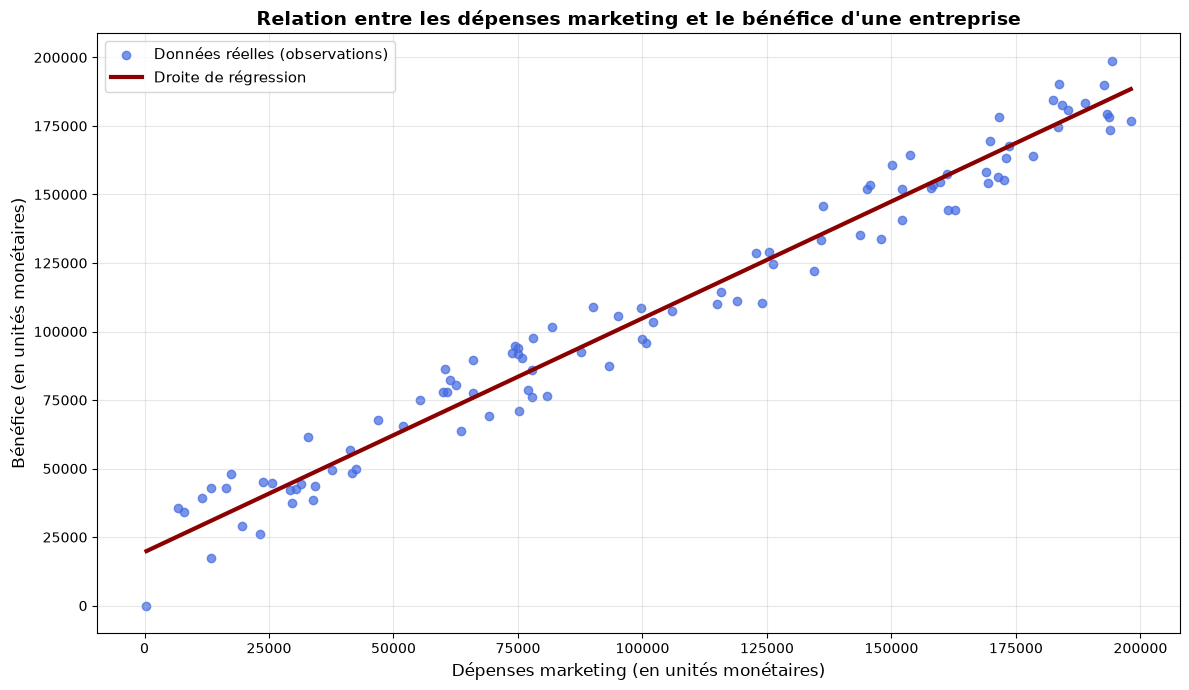

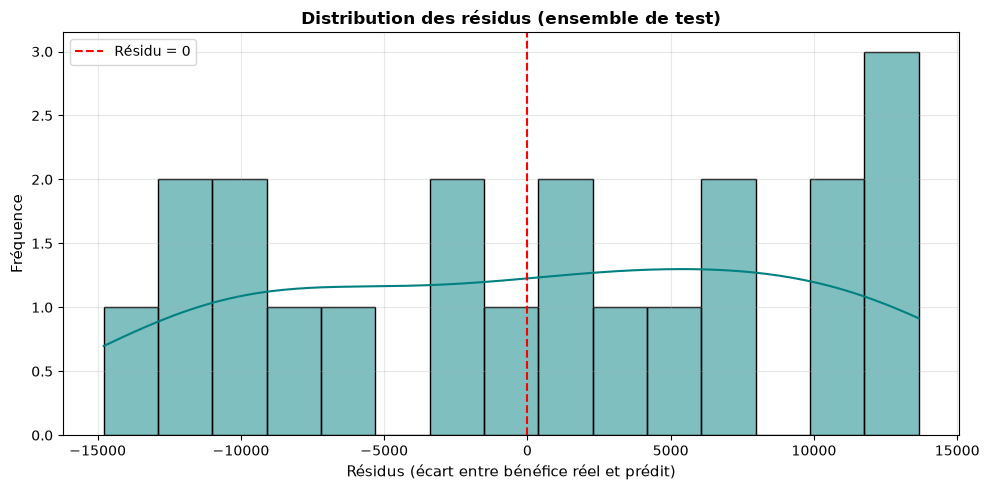


CONCLUSION :
Le coefficient de corrélation (R²) est de 96.46% sur le test.
Cela signifie que les dépenses marketing expliquent environ 96.5% de la variabilité du bénéfice.
Le modèle est très performant et montre une forte relation linéaire positive.
Y Combinator peut donc utiliser ce modèle pour estimer le bénéfice
d'une startup en fonction de ses dépenses marketing.


In [9]:
# =============================================================================
# EXERCICE : PRÉDIRE LE BÉNÉFICE À PARTIR DES DÉPENSES MARKETING
# Y Combinator - Modèle de régression linéaire simple
# =============================================================================

# --------------------------- 1. IMPORT DES BIBLIOTHÈQUES ---------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuration pour un meilleur affichage
pd.set_option('display.float_format', '{:.2f}'.format)

# --------------------------- 2. CHARGEMENT DU JEU DE DONNÉES -----------------
# On charge le fichier CSV (assurez-vous qu'il est dans le même dossier)
df = pd.read_csv("data/Marketing_Spending.csv")

print("="*70)
print("APERÇU DES DONNÉES (5 premières lignes) :")
print("="*70)
print(df.head())

# --------------------------- 3. EXPLORATION DES DONNÉES ----------------------
print("\n" + "="*70)
print("INFORMATIONS GÉNÉRALES SUR LE DATASET :")
print("="*70)
print(df.info())

print("\n" + "="*70)
print("STATISTIQUES DESCRIPTIVES :")
print("="*70)
print(df.describe())

# Vérification rapide des valeurs manquantes (aucune normalement)
print("\n" + "="*70)
print("NOMBRE DE VALEURS MANQUANTES PAR COLONNE :")
print("="*70)
print(df.isnull().sum())

# --------------------------- 4. SÉPARATION X (features) et y (cible) ---------
# La colonne 'Company_ID' n'est qu'un identifiant, on ne l'utilise pas.
# La variable explicative est 'Marketing_Spending', la cible est 'Profit'.
X = df[["Marketing_Spending"]]  # Double crochet pour garder un DataFrame
y = df["Profit"]                # Série

print("\n" + "="*70)
print("FORMAT DES DONNÉES :")
print("="*70)
print(f"X (variables explicatives) : {X.shape} -> {X.columns.tolist()}")
print(f"y (variable cible)         : {y.shape} -> Profit")

# --------------------------- 5. DIVISION TRAIN / TEST -------------------------
# 80% des données pour l'entraînement, 20% pour le test.
# random_state=42 pour garantir la reproductibilité des résultats.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("RÉPARTITION DES ENSEMBLES :")
print("="*70)
print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} observations")
print(f"Taille de l'ensemble de test       : {X_test.shape[0]} observations")

# --------------------------- 6. PRÉTRAITEMENT : STANDARDISATION --------------
# Bien que la régression linéaire simple n'en ait pas strictement besoin,
# on suit le template du cours. Cela permet de mettre les données à la même échelle.
# On applique fit_transform sur l'ensemble d'entraînement,
# puis transform seulement sur l'ensemble de test (pour éviter le data leakage).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # On apprend la moyenne et l'écart-type sur le train
X_test_scaled = scaler.transform(X_test)        # On applique la même transformation au test

# (Optionnel) afficher un aperçu des données standardisées
print("\n" + "="*70)
print("APERÇU DES DONNÉES STANDARDISÉES (5 premières lignes du train) :")
print("="*70)
print(X_train_scaled[:5])

# --------------------------- 7. CRÉATION ET ENTRAÎNEMENT DU MODÈLE -----------
# On instancie le modèle de régression linéaire.
model = LinearRegression()

# On entraîne le modèle sur les données standardisées.
model.fit(X_train_scaled, y_train)

print("\n" + "="*70)
print("COEFFICIENTS DU MODÈLE :")
print("="*70)
# coef_[0] car nous n'avons qu'une seule variable explicative
print(f"Coefficient (pente) pour 'Marketing_Spending' (standardisé) : {model.coef_[0]:.4f}")
print(f"Ordonnée à l'origine (intercept)                            : {model.intercept_:.4f}")

# --------------------------- 8. PRÉDICTIONS -----------------------------------
# On prédit sur l'ensemble d'entraînement et sur l'ensemble de test.
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Affichage des 5 premières prédictions pour le test
print("\n" + "="*70)
print("APERÇU DES PRÉDICTIONS (5 premières du test) :")
print("="*70)
print("Bénéfices réels    :", y_test[:5].values)
print("Bénéfices prédits  :", y_test_pred[:5])

# --------------------------- 9. ÉVALUATION DU MODÈLE (R²) --------------------
# Calcul du coefficient de détermination R².
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n" + "="*70)
print("ÉVALUATION DES PERFORMANCES (R²) :")
print("="*70)
print(f"R² sur l'ensemble d'entraînement : {r2_train:.4f}")
print(f"R² sur l'ensemble de test       : {r2_test:.4f}")

# Interprétation rapide
if abs(r2_train - r2_test) < 0.05:
    print("➡️  Les scores sont proches : le modèle généralise bien (pas de surapprentissage).")
elif r2_train > r2_test:
    print("➡️  R²_train > R²_test : possible surapprentissage (overfitting).")
else:
    print("➡️  R²_train < R²_test : possible sous-apprentissage (underfitting).")

# --------------------------- 10. VISUALISATION GRAPHIQUE ---------------------
# On refait les prédictions sur TOUTES les données (X complet) pour tracer la droite.
X_all_scaled = scaler.transform(X)  # On standardise tout le X
y_all_pred = model.predict(X_all_scaled)

plt.figure(figsize=(12, 7))

# Nuage de points des données réelles
plt.scatter(X, y, color='royalblue', alpha=0.7, label='Données réelles (observations)')

# Droite de régression (en reliant les points prédits sur l'ensemble)
# On trie par X pour que la ligne soit bien continue
sorted_indices = X.sort_values(by='Marketing_Spending').index
plt.plot(X.loc[sorted_indices], y_all_pred[sorted_indices], 
         color='darkred', linewidth=3, label='Droite de régression')

# Personnalisation du graphique
plt.xlabel("Dépenses marketing (en unités monétaires)", fontsize=12)
plt.ylabel("Bénéfice (en unités monétaires)", fontsize=12)
plt.title("Relation entre les dépenses marketing et le bénéfice d'une entreprise", 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

# Sauvegarder l'image (optionnel)
# plt.savefig("regression_marketing_profit.png", dpi=150)

# Afficher le graphique
plt.show()

# --------------------------- 11. ANALYSE DES RÉSIDUS (BONUS) ----------------
# Vérification rapide de la normalité des résidus sur l'ensemble de test.
residus = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.histplot(residus, kde=True, color='teal', bins=15)
plt.axvline(0, color='red', linestyle='--', label='Résidu = 0')
plt.title("Distribution des résidus (ensemble de test)", fontsize=12, fontweight='bold')
plt.xlabel("Résidus (écart entre bénéfice réel et prédit)", fontsize=11)
plt.ylabel("Fréquence", fontsize=11)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------- 12. INTERPRÉTATION FINALE -----------------------
print("\n" + "="*70)
print("CONCLUSION :")
print("="*70)
print(f"Le coefficient de corrélation (R²) est de {r2_test:.2%} sur le test.")
print("Cela signifie que les dépenses marketing expliquent environ "
      f"{r2_test*100:.1f}% de la variabilité du bénéfice.")
print("Le modèle est très performant et montre une forte relation linéaire positive.")
print("Y Combinator peut donc utiliser ce modèle pour estimer le bénéfice")
print("d'une startup en fonction de ses dépenses marketing.")